# Train experts that merge well

We start from a pretrained ViT-Tiny and train two experts: one recognizes **CIFAR-10 objects**, and the other reads **SVHN digits**. We train each expert with ordinary fine-tuning (FT) and with SMAT, then merge each pair into one encoder.

Run the cells below to compare the base, each expert on its own task, and the merged models. We use the published SMAT implementation directly.

[Paper](https://arxiv.org/abs/2609.33437) · [Code](https://github.com/egangu/smat) · [Data](https://huggingface.co/datasets/yanggangu/SMAT-Tiny-Demo)


### 1. Prepare the runtime

Run all cells in order. We use CPU with four threads and seed 0 by default; change `DEVICE` to `"cuda"` to use a GPU. Allow about three minutes on a server CPU, plus the first download: approximately 23 MB of weights and 22 MB of data.

The next cell installs missing dependencies and fetches the pinned support files.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import hashlib

SUPPORT_REVISION = "a87c58ad4027a2e27e8909987e2b955c1182947f"
SUPPORT_FILES = {'demo_setup.py': 'b4e2bd5af77d7e38c23425803a6cb9bafce73cfb31e88c20bb29e4ba1a9c37f7', 'demo_utils.py': '7dc5e5792748a6a6f017e638ac597b7c1abd77046ab642aded0a75218fbb4aff', 'demo_experiment.py': '883ab69ef46483797761a42a5ba02cd90a2328ea96d39cb9a2cdd3aa33c6da89'}
for name, digest in SUPPORT_FILES.items():
    if not Path(name).exists():
        urlretrieve(f"https://raw.githubusercontent.com/egangu/smat/{SUPPORT_REVISION}/examples/{name}", name)
    assert hashlib.sha256(Path(name).read_bytes()).hexdigest() == digest, f"Unexpected helper: {name}"
from demo_setup import ensure_runtime
ensure_runtime()


In [2]:
import os
from copy import deepcopy
import torch
from torch import nn
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
from smat.train.updates import FTStepper, SMATStepper
from demo_utils import load_encoder, load_data, show_examples, show_results
from demo_experiment import fit_heads

DEVICE = os.environ.get("SMAT_DEMO_DEVICE", "cpu")  # Change to "cuda" if available.
SEED = 0
torch.set_num_threads(4)
torch.manual_seed(1729)  # Same initialization for every expert.
TASKS = ("cifar10", "svhn")


/work/home/yggu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Load the base and the two tasks

Load [ViT-Tiny from Hugging Face](https://huggingface.co/timm/vit_tiny_patch16_224.augreg_in21k_ft_in1k) and 2,000 training images per task. Resize images to 64×64 and cache the frozen patch embeddings to avoid repeating that work.

Before training experts, fit one classification head per task while keeping the pretrained encoder unchanged. Freeze both heads afterward. We call this starting model **Base**; FT and SMAT will both start here and train all 12 Transformer blocks.


In [3]:
class TwoTaskViT(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = nn.Sequential(deepcopy(backbone.blocks), deepcopy(backbone.norm))
        self.heads = nn.ModuleDict({task: nn.Linear(192, 10) for task in TASKS})

    def features(self, tokens):
        return self.backbone(tokens)[:, 0]

    def forward(self, tokens, task):
        return self.heads[task](self.features(tokens))


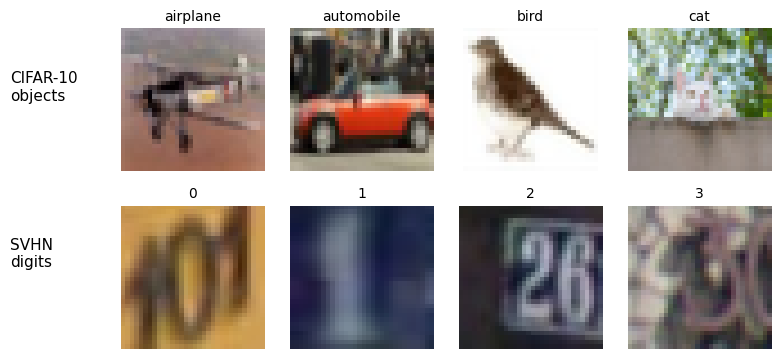

In [4]:
encoder = load_encoder().to(DEVICE).eval()
base = TwoTaskViT(encoder).to(DEVICE).eval()
data = load_data(encoder, DEVICE)
fit_heads(base, data)
del encoder
figure = show_examples()
plt.show()


### 3. Train the experts

Train an object expert and a digit expert with each method. Each expert sees only its own task. Give FT and SMAT the same initialization, minibatches, learning rate and 600 updates.

For SMAT, use `SMATStepper` to simulate **Scale · Mask · Perturb** every fourth update. It computes gradients at the transformed weights, restores the expert, and applies the update.


In [5]:
SMAT_SETTINGS = {
    "backend": "eager",
    "scale": {"alpha_min": 0.1},
    "mask": {"probability": 0.8},
    "perturb": {"rms": 0.01},
    "smat": {"interval": 4},
}

def train_expert(base, data, task, method, seed=0):
    """Same initialization, Adam, batches and 600 updates for FT and SMAT."""
    if method not in {"FT", "SMAT"}:
        raise ValueError("method must be FT or SMAT")
    expert = deepcopy(base)
    parameters = list(expert.named_parameters())
    optimizer = torch.optim.Adam([p for _, p in parameters if p.requires_grad], lr=1e-4)
    linear_weights = {n for n, p in parameters if p.requires_grad and p.ndim == 2}
    stepper = (
        FTStepper(parameters, optimizer) if method == "FT" else
        SMATStepper(parameters, optimizer, SMAT_SETTINGS, seed, linear_weights)
    )
    x, y = data[task]["train"]
    rng = torch.Generator().manual_seed(seed + 100)
    for _ in range(600):
        ids = torch.randint(len(y), (32,), generator=rng).to(y.device)
        stepper.step(lambda: F.cross_entropy(expert(x[ids], task), y[ids]))
    return expert.eval()


In [6]:
experts = {}
for method in ("FT", "SMAT"):
    experts[method] = []
    for task in TASKS:
        print(f"Training {method}: {task}", flush=True)
        experts[method].append(train_expert(base, data, task, method, SEED))


Training FT: cifar10


Training FT: svhn


Training SMAT: cifar10


Training SMAT: svhn


### 4. Check each expert on its own task

Evaluate the object expert on CIFAR-10 and the digit expert on SVHN, using 2,000 held-out images per task. The **experts** rows combine these two separate evaluations; their mean requires **two encoders**. This tells us what each pair learned before merging.


In [7]:
@torch.no_grad()
def evaluate(model, data):
    """Evaluate one shared model, or a mapping of task to its own expert."""
    scores = {}
    for task in TASKS:
        task_model = model[task] if isinstance(model, dict) else model
        x, y = data[task]["test"]
        predictions = torch.cat([task_model(batch, task).argmax(1) for batch in x.split(128)])
        scores[task] = 100 * (predictions == y).sum().item() / len(y)
    scores["Mean"] = sum(scores.values()) / len(TASKS)
    return scores


In [8]:
rows = {"Base": evaluate(base, data)}
for method in ("FT", "SMAT"):
    own_task_models = dict(zip(TASKS, experts[method]))
    rows[f"{method} experts"] = evaluate(own_task_models, data)
pd.DataFrame(rows).T.rename(columns={"cifar10": "CIFAR-10", "svhn": "SVHN"}).round(2)


,CIFAR-10,SVHN,Mean
Base,44.55,21.25,32.90
FT experts,65.30,71.35,68.32
SMAT experts,70.45,77.90,74.18


### 5. Merge the experts and compare

Subtract Base from each expert to get its update, then combine the two updates:
$\theta_{\rm merged}=\theta_{\rm base}+\lambda(\Delta_{\rm objects}+\Delta_{\rm digits})$.

Use $\lambda=0.5$ for **AVG** and $\lambda=0.75$ for **Task Arithmetic (TA)**, with the same coefficient for FT and SMAT. Keep the two frozen heads. To predict, choose the head for the task and run it on the **single merged encoder**.

Evaluate the merged models on the same test images, then compare their accuracy with Base and the separate experts.


In [9]:
def merge_experts(base, experts, coefficient):
    """AVG: 0.5. TA: 0.75. Keep both task-specific heads unchanged."""
    merged = deepcopy(base)
    anchor = base.backbone.state_dict()
    states = [expert.backbone.state_dict() for expert in experts]
    merged.backbone.load_state_dict({
        name: value + coefficient * sum(state[name] - value for state in states)
        for name, value in anchor.items()
    })
    return merged.eval()


In [10]:
for method in ("FT", "SMAT"):
    for merger, coefficient in (("AVG", 0.5), ("TA", 0.75)):
        merged = merge_experts(base, experts[method], coefficient)
        rows[f"{method} {merger}"] = evaluate(merged, data)
        del merged
table = pd.DataFrame(rows).T.rename(columns={"cifar10": "CIFAR-10", "svhn": "SVHN"})
table.insert(0, "Encoders", [2 if name.endswith("experts") else 1 for name in table.index])
table.round(2)


,Encoders,CIFAR-10,SVHN,Mean
Base,1,44.55,21.25,32.90
FT experts,2,65.30,71.35,68.32
SMAT experts,2,70.45,77.90,74.18
FT AVG,1,61.20,58.30,59.75
FT TA,1,61.85,67.90,64.88
SMAT AVG,1,65.25,67.05,66.15
SMAT TA,1,66.55,72.90,69.72


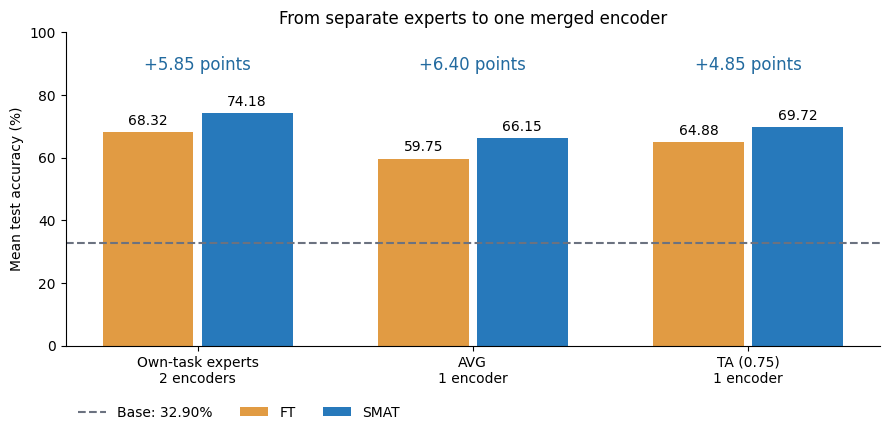

AVG: SMAT − FT = +6.40 percentage points
TA: SMAT − FT = +4.85 percentage points


In [11]:
figure = show_results(rows)
plt.show()
for merger in ("AVG", "TA"):
    gain = rows[f"SMAT {merger}"]["Mean"] - rows[f"FT {merger}"]["Mean"]
    print(f"{merger}: SMAT − FT = {gain:+.2f} percentage points")


### Read the results

Compare FT and SMAT within each group. The first group measures each expert on its own task; AVG and TA measure how well one encoder handles both tasks after merging. The dashed line marks Base.

In the recorded CPU run, both merging methods improve on Base, and SMAT gains **6.40 points with AVG** and **4.85 with TA** over FT. Across five CUDA seeds, the mean gains are **5.07** and **4.07 points**. Your results can vary with the seed and hardware.

We keep the recipe fixed throughout this notebook; no development-set search is needed. See the [experiment notes and full records](https://github.com/egangu/smat/tree/main/examples) for the protocol and per-seed results.
